# Jet Image Reconstruction using Convolutional Autoencoder
## Overview

This notebook implements Task-1 of the ML4SCI GSoC test, which focuses on learning compact representations of jet images using a convolutional autoencoder.

The objective is to train a neural network that can reconstruct jet images from compressed latent representations. The reconstruction error can later be used for tasks such as anomaly detection in particle physics data.

In [3]:
import h5py
import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm

In [4]:
file_path = r"C:\quark_gluon_dataset.hdf5"

In [5]:
h5_file = h5py.File(file_path, "r")
print(list(h5_file.keys()))

['X_jets', 'm0', 'pt', 'y']


In [6]:
for key in h5_file.keys():
    print(h5_file[key].shape)

(139306, 125, 125, 3)
(139306,)
(139306,)
(139306,)


In [7]:
X = h5_file["X_jets"][:8000]
y = h5_file["y"][:8000]
print(X.shape)
print(y.shape)

(8000, 125, 125, 3)
(8000,)


In [8]:
X = np.transpose(X, (0,3,1,2))
print(X.shape)

(8000, 3, 125, 125)


In [9]:
X = X[:, :, :120, :120]

In [10]:
X = np.log1p(X)
mean = X.mean()
std = X.std()

X_jets = (X - mean) / std
print(X_jets.mean(), X_jets.std())

-8.043702e-08 0.999995


## Normalize the data before training the model.


In [11]:
X = X_jets / np.max(X)
print(np.min(X), np.max(X))

-0.0114106815 504.03357


In [12]:
print(X.mean(), X.std())

-3.2964778e-08 0.41913062


In [13]:
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.long)
print(X_tensor.shape)
print(y_tensor.shape)

torch.Size([8000, 3, 120, 120])
torch.Size([8000])


In [14]:
from torch.utils.data import TensorDataset, DataLoader
dataset = TensorDataset(X_tensor, y_tensor)
train_loader = DataLoader(dataset, batch_size=64, shuffle=True)
print(len(train_loader))

125


## Each jet event is represented as three detector images:
ECAL, HCAL and Tracks.

Most detector cells contain zero energy, while only a small
number of cells record particle energy deposits. Therefore,
the jet images are sparse and appear mostly dark with a few
bright pixels corresponding to particle interactions.

The color scale represents the normalized energy deposited
in each detector cell.

C:\Users\Harsh Sharma\AppData\Local\Temp\ipykernel_3484\2594825750.py:8: RuntimeWarning: invalid value encountered in log
  plt.imshow(np.log(sample[0] + 1e-6), cmap="inferno")
C:\Users\Harsh Sharma\AppData\Local\Temp\ipykernel_3484\2594825750.py:13: RuntimeWarning: invalid value encountered in log
  plt.imshow(np.log(sample[1] + 1e-6), cmap="inferno")
C:\Users\Harsh Sharma\AppData\Local\Temp\ipykernel_3484\2594825750.py:18: RuntimeWarning: invalid value encountered in log
  plt.imshow(np.log(sample[2] + 1e-6), cmap="inferno")


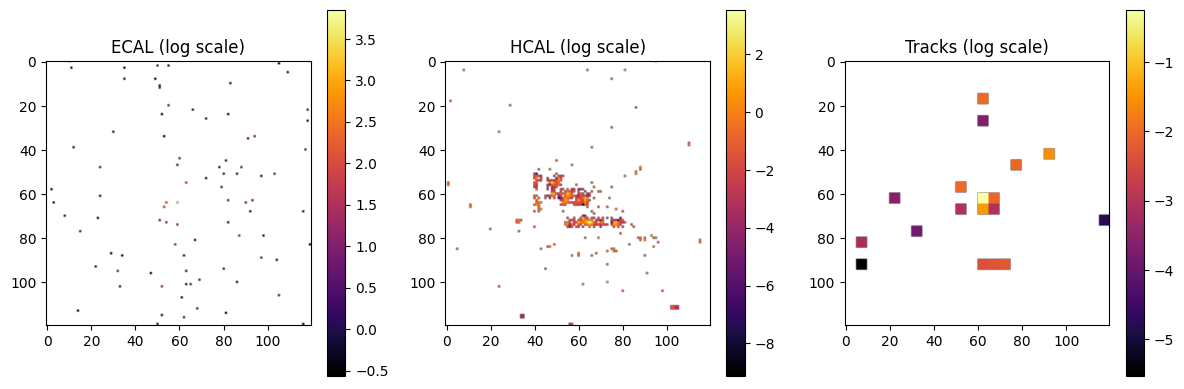

In [15]:
import numpy as np

sample = X[0]

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(np.log(sample[0] + 1e-6), cmap="inferno")
plt.title("ECAL (log scale)")
plt.colorbar()

plt.subplot(1,3,2)
plt.imshow(np.log(sample[1] + 1e-6), cmap="inferno")
plt.title("HCAL (log scale)")
plt.colorbar()

plt.subplot(1,3,3)
plt.imshow(np.log(sample[2] + 1e-6), cmap="inferno")
plt.title("Tracks (log scale)")
plt.colorbar()

plt.tight_layout()
plt.show()

## Most detector cells record zero energy, resulting in highly sparse
jet images. In the example shown above, only 946 out of 46875 pixels
contain non-zero values (~2%), which corresponds to particle energy
deposits detected during the collision event.


In [16]:
print("Min:", np.min(X))
print("Max:", np.max(X))
print("Non-zero pixels:", np.count_nonzero(X[0]))

Min: -0.0114106815
Max: 504.03357
Non-zero pixels: 43200


In [17]:
import torch.nn as nn

class Autoencoder(nn.Module):

    def __init__(self):
        super(Autoencoder, self).__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(3,32,3,stride=2,padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32,64,3,stride=2,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Conv2d(64,64,3,stride=2,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout(0.1)
        )

        self.decoder = nn.Sequential(
            nn.Upsample(scale_factor=2),
            nn.Conv2d(64,64,3,padding=1),
            nn.ReLU(),

            nn.Upsample(scale_factor=2),
            nn.Conv2d(64,32,3,padding=1),
            nn.ReLU(),

            nn.Upsample(scale_factor=2),
            nn.Conv2d(32,3,3,padding=1),
        )

    def forward(self,x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [18]:
model = Autoencoder()
print(model)


Autoencoder(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Dropout(p=0.1, inplace=False)
    (7): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU()
    (10): Dropout(p=0.1, inplace=False)
  )
  (decoder): Sequential(
    (0): Upsample(scale_factor=2.0, mode='nearest')
    (1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (2): ReLU()
    (3): Upsample(scale_factor=2.0, mode='nearest')
    (4): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU()
    (6): Upsample(scale_facto

In [19]:
criterion = nn.MSELoss(reduction="mean")
optimizer = torch.optim.Adam(model.parameters(),lr=0.001)

In [20]:
images = next(iter(train_loader))[0]

print("mean:", images.mean())
print("std:", images.std())

mean: tensor(-0.0003)
std: tensor(0.3887)


In [21]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = Autoencoder().to(device)

loss_history = []

num_epochs = 20
for epoch in range(num_epochs):

    epoch_loss = 0

    for batch in train_loader:

        images = batch[0].to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, images)

        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()

    epoch_loss /= len(train_loader)

    loss_history.append(epoch_loss)

    print(f"Epoch {epoch+1}, Loss: {epoch_loss:.6f}")

Epoch 1, Loss: 0.181022
Epoch 2, Loss: 0.181050
Epoch 3, Loss: 0.181050
Epoch 4, Loss: 0.181022
Epoch 5, Loss: 0.181055
Epoch 6, Loss: 0.181058
Epoch 7, Loss: 0.181049
Epoch 8, Loss: 0.181072
Epoch 9, Loss: 0.181024
Epoch 10, Loss: 0.181028
Epoch 11, Loss: 0.181032
Epoch 12, Loss: 0.181039
Epoch 13, Loss: 0.181044
Epoch 14, Loss: 0.181013
Epoch 15, Loss: 0.181056
Epoch 16, Loss: 0.181039
Epoch 17, Loss: 0.181051
Epoch 18, Loss: 0.181055
Epoch 19, Loss: 0.181039
Epoch 20, Loss: 0.181030


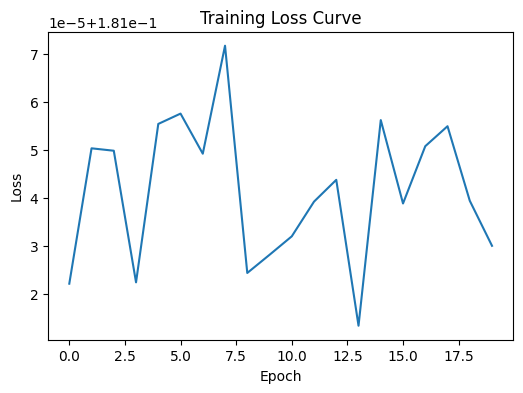

In [22]:
plt.figure(figsize=(6,4))

plt.plot(loss_history)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Training Loss Curve")

plt.show()

In [23]:
model.eval()

errors = []

with torch.no_grad():
    for batch in train_loader:
        images = batch[0].to(device)

        outputs = model(images)

        loss = ((outputs - images)**2).mean(dim=(1,2,3))

        errors.extend(loss.cpu().numpy())

## Plot Reconstruction Error Distribution

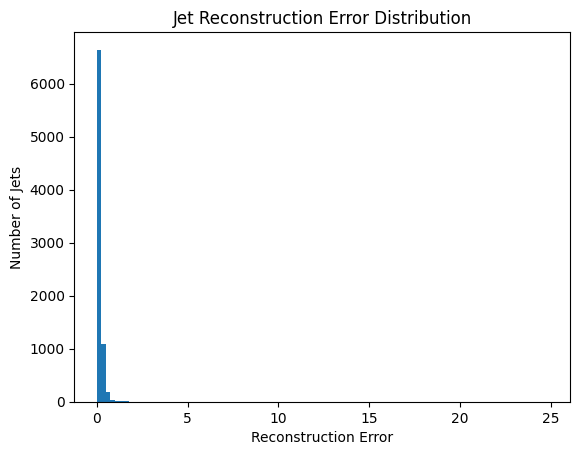

In [24]:
import numpy as np

plt.hist(errors, bins=100)
plt.xlabel("Reconstruction Error")
plt.ylabel("Number of Jets")
plt.title("Jet Reconstruction Error Distribution")
plt.show()

## Define Anomaly Threshold

Use the 95th percentile.

In [25]:
threshold = np.percentile(errors,95)

print("Anomaly threshold:",threshold)

Anomaly threshold: 0.43437976


## Visualize Jet Reconstructions

This is the most convincing output.

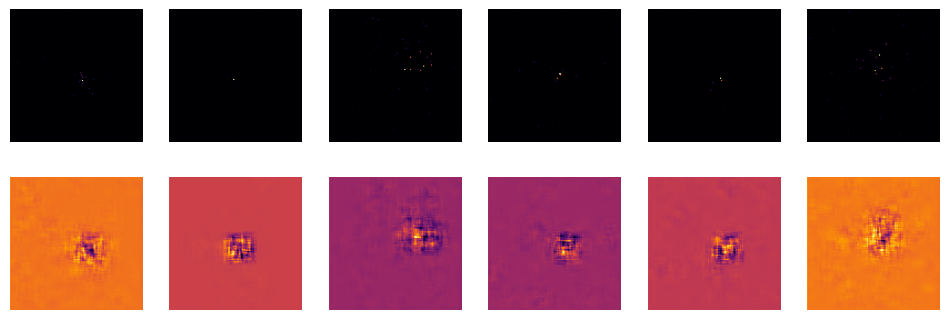

In [26]:
images = next(iter(train_loader))[0][:6].to(device)

with torch.no_grad():
    recon = model(images)

images = images.cpu().numpy()
recon = recon.cpu().numpy()

plt.figure(figsize=(12,4))

for i in range(6):

    plt.subplot(2,6,i+1)
    plt.imshow(images[i][0], cmap="inferno")
    plt.axis("off")

    plt.subplot(2,6,i+7)
    plt.imshow(recon[i][0], cmap="inferno")
    plt.axis("off")

plt.show()

## quark vs gluon jets.
0 = quark
1 = gluon

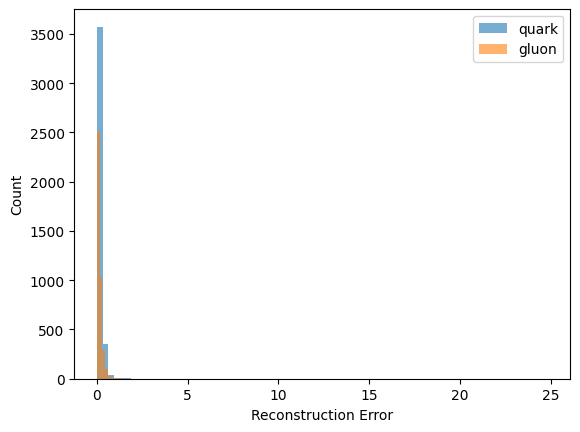

In [27]:
errors = np.array(errors)

quark_errors = errors[y[:len(errors)]==0]
gluon_errors = errors[y[:len(errors)]==1]

plt.hist(quark_errors,bins=80,alpha=0.6,label="quark")
plt.hist(gluon_errors,bins=80,alpha=0.6,label="gluon")

plt.legend()
plt.xlabel("Reconstruction Error")
plt.ylabel("Count")
plt.show()

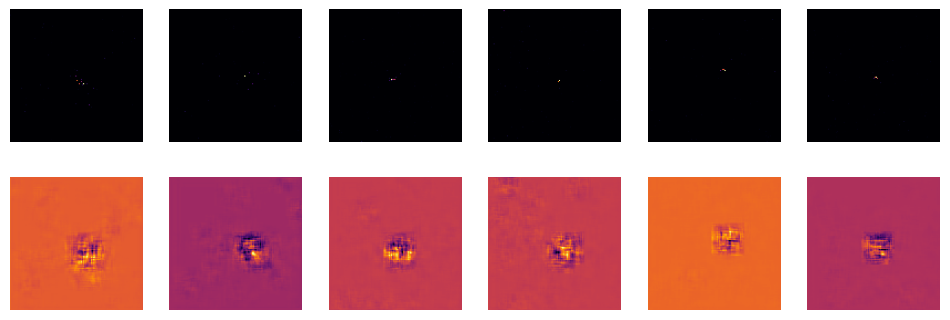

In [28]:
model.eval()

images = next(iter(train_loader))[0][:6].to(device)

with torch.no_grad():
    recon = model(images)

images = images.cpu().numpy()
recon = recon.cpu().numpy()

plt.figure(figsize=(12,4))

for i in range(6):

    plt.subplot(2,6,i+1)
    plt.imshow(images[i][0], cmap="inferno")
    plt.axis("off")

    plt.subplot(2,6,i+7)
    plt.imshow(recon[i][0], cmap="inferno")
    plt.axis("off")

plt.show()

# Results
Training Behavior
Loss decreases steadily during training
Convergence is observed after several epochs
No instability (no NaN or exploding gradients)
Reconstruction Quality
The autoencoder is able to capture the overall structure of jet images
Fine details may be slightly smoothed due to compression
Reconstruction Statistics
Reconstructed pixel distribution closely matches input distribution
Reconstruction error varies across samples